In [ ]:
import pandas as pd

dataset = pd.read_csv("Placement.csv")
dataset.drop("sl_no", axis=1)
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [2]:
# adding mean, median, mode, percentiles (Q1, Q2, Q3, Q4)
from collections import defaultdict

num_columns = dataset.select_dtypes(include="number")
col_names = num_columns.columns
description = num_columns.describe()

calculations = defaultdict(
    dict
)  # defaultdict --> Collector function for dynamic dictionary manipulation

for column in col_names:
    col = num_columns[column]
    median = col.median()

    num_columns.loc[col.isna(), column] = 0  # Replacing NaN with 0

    calculations[column] = {
        "Mean": col.mean(),
        "Median": median,
        "Mode": col.mode()[0],
        "Q1-25%": description[column]["25%"],
        "Q2-50%": description[column]["50%"],
        "Q3-75%": description[column]["75%"],
        "Q4-100%": description[column]["max"],
    }
print(num_columns)
calculations

     sl_no  ssc_p  hsc_p  degree_p  etest_p  mba_p    salary
0        1  67.00  91.00     58.00     55.0  58.80  270000.0
1        2  79.33  78.33     77.48     86.5  66.28  200000.0
2        3  65.00  68.00     64.00     75.0  57.80  250000.0
3        4  56.00  52.00     52.00     66.0  59.43       0.0
4        5  85.80  73.60     73.30     96.8  55.50  425000.0
..     ...    ...    ...       ...      ...    ...       ...
210    211  80.60  82.00     77.60     91.0  74.49  400000.0
211    212  58.00  60.00     72.00     74.0  53.62  275000.0
212    213  67.00  67.00     73.00     59.0  69.72  295000.0
213    214  74.00  66.00     58.00     70.0  60.23  204000.0
214    215  62.00  58.00     53.00     89.0  60.22       0.0

[215 rows x 7 columns]


defaultdict(dict,
            {'sl_no': {'Mean': np.float64(108.0),
              'Median': np.float64(108.0),
              'Mode': np.int64(1),
              'Q1-25%': np.float64(54.5),
              'Q2-50%': np.float64(108.0),
              'Q3-75%': np.float64(161.5),
              'Q4-100%': np.float64(215.0)},
             'ssc_p': {'Mean': np.float64(67.30339534883721),
              'Median': np.float64(67.0),
              'Mode': np.float64(62.0),
              'Q1-25%': np.float64(60.599999999999994),
              'Q2-50%': np.float64(67.0),
              'Q3-75%': np.float64(75.7),
              'Q4-100%': np.float64(89.4)},
             'hsc_p': {'Mean': np.float64(66.33316279069768),
              'Median': np.float64(65.0),
              'Mode': np.float64(63.0),
              'Q1-25%': np.float64(60.9),
              'Q2-50%': np.float64(65.0),
              'Q3-75%': np.float64(73.0),
              'Q4-100%': np.float64(97.7)},
             'degree_p': {'Mean': np.fl

In [3]:
# add iqr, lower_range, higher_range
for column in num_columns.columns:
    q1 = calculations[column]["Q1-25%"]
    q3 = calculations[column]["Q3-75%"]
    iqr = q3 - q1
    calculations[column]["IQR"] = iqr
    calculations[column]["lower_outlier_range"] = q1 - 1.5 * iqr
    calculations[column]["higher_outlier_range"] = q3 + 1.5 * iqr

In [4]:
pd.DataFrame(calculations)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Mode,1.0,62.000000,63.000000,65.000000,60.000000,56.700000,300000.000000
Q1-25%,54.5,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
Q2-50%,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Q3-75%,161.5,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
Q4-100%,215.0,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000
IQR,107.0,15.100000,12.100000,11.000000,23.500000,8.310000,60000.000000
lower_outlier_range,-106.0,37.950000,42.750000,44.500000,24.750000,45.480000,150000.000000
higher_outlier_range,322.0,98.350000,91.150000,88.500000,118.750000,78.720000,390000.000000


In [5]:
# adding possible outliers count
for column in num_columns:
    calculations[column]["min"] = min(num_columns[column])
    calculations[column]["max"] = max(num_columns[column])
    lower_outlier = calculations[column]["lower_outlier_range"]
    higher_outlier = calculations[column]["higher_outlier_range"]
    col = num_columns[column]
    calculations[column]["outliers_count"] = col[
        (col < lower_outlier) | (col > higher_outlier)
    ].count()

calculated = pd.DataFrame(calculations)
calculated

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Mode,1.0,62.000000,63.000000,65.000000,60.000000,56.700000,300000.000000
Q1-25%,54.5,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
Q2-50%,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Q3-75%,161.5,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
Q4-100%,215.0,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000
IQR,107.0,15.100000,12.100000,11.000000,23.500000,8.310000,60000.000000
lower_outlier_range,-106.0,37.950000,42.750000,44.500000,24.750000,45.480000,150000.000000
higher_outlier_range,322.0,98.350000,91.150000,88.500000,118.750000,78.720000,390000.000000


In [ ]:
# Replace Outliers
for col in num_columns:
    lower = calculations[col]["lower_outlier_range"]
    higher = calculations[col]["higher_outlier_range"]
    num_columns[col] = num_columns[col].clip(
        lower, higher
    )  # clip() method bounds the values between lower and higher
num_columns

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,1,67.00,91.00,58.00,55.0,58.80,270000.0
1,2,79.33,78.33,77.48,86.5,66.28,200000.0
2,3,65.00,68.00,64.00,75.0,57.80,250000.0
3,4,56.00,52.00,52.00,66.0,59.43,150000.0
4,5,85.80,73.60,73.30,96.8,55.50,390000.0
...,...,...,...,...,...,...,...
210,211,80.60,82.00,77.60,91.0,74.49,390000.0
211,212,58.00,60.00,72.00,74.0,53.62,275000.0
212,213,67.00,67.00,73.00,59.0,69.72,295000.0
213,214,74.00,66.00,58.00,70.0,60.23,204000.0


In [7]:
# verifying data after replacing outliers

for column in num_columns:
    lower = calculations[column]["lower_outlier_range"]
    higher = calculations[column]["higher_outlier_range"]
    outlier_count = num_columns[column][
        (num_columns[column] < lower) | (num_columns[column] > higher)
    ].count()
    calculations[column]["revised_outlier_count"] = outlier_count

pd.DataFrame(calculations)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Mode,1.0,62.000000,63.000000,65.000000,60.000000,56.700000,300000.000000
Q1-25%,54.5,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
Q2-50%,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Q3-75%,161.5,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
Q4-100%,215.0,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000
IQR,107.0,15.100000,12.100000,11.000000,23.500000,8.310000,60000.000000
lower_outlier_range,-106.0,37.950000,42.750000,44.500000,24.750000,45.480000,150000.000000
higher_outlier_range,322.0,98.350000,91.150000,88.500000,118.750000,78.720000,390000.000000


In [ ]:
frequency = {}

for column in num_columns:
    freq = num_columns[column].value_counts().sort_index()

    frequency[column] = pd.DataFrame(
        {
            "value": freq.index,
            "frequency": freq.values,
            "relative_frequency": freq.values / freq.sum(),
            "cumulative_frequency": freq.cumsum().values,
        }
    )

final_table = pd.concat(frequency, names=["column"]).reset_index(level=0)

final_table

,column,value,frequency,relative_frequency,cumulative_frequency
0,sl_no,1.0,1,0.004651,1
1,sl_no,2.0,1,0.004651,2
2,sl_no,3.0,1,0.004651,3
3,sl_no,4.0,1,0.004651,4
4,sl_no,5.0,1,0.004651,5
...,...,...,...,...,...
32,salary,340000.0,1,0.004651,190
33,salary,350000.0,3,0.013953,193
34,salary,360000.0,6,0.027907,199
35,salary,380000.0,1,0.004651,200


In [ ]:
for col in num_columns:
    calculations[col]["Skewness"] = num_columns[col].skew()
    calculations[col]["Kurtosis"] = num_columns[col].kurtosis()
pd.DataFrame(calculations)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Mode,1.0,62.000000,63.000000,65.000000,60.000000,56.700000,300000.000000
Q1-25%,54.5,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
Q2-50%,108.0,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
Q3-75%,161.5,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
Q4-100%,215.0,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000
IQR,107.0,15.100000,12.100000,11.000000,23.500000,8.310000,60000.000000
lower_outlier_range,-106.0,37.950000,42.750000,44.500000,24.750000,45.480000,150000.000000
higher_outlier_range,322.0,98.350000,91.150000,88.500000,118.750000,78.720000,390000.000000


In [10]:
for col in num_columns:
    calculations[col]["variance"] = round(num_columns[col].var(), 2)
    calculations[col]["standard_deviation"] = round(num_columns[col].std(), 2)
pd.DataFrame(calculations)

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.00,67.303395,66.333163,66.370186,72.100558,62.278186,2.886554e+05
Median,108.00,67.000000,65.000000,66.000000,71.000000,62.000000,2.650000e+05
Mode,1.00,62.000000,63.000000,65.000000,60.000000,56.700000,3.000000e+05
Q1-25%,54.50,60.600000,60.900000,61.000000,60.000000,57.945000,2.400000e+05
Q2-50%,108.00,67.000000,65.000000,66.000000,71.000000,62.000000,2.650000e+05
Q3-75%,161.50,75.700000,73.000000,72.000000,83.500000,66.255000,3.000000e+05
Q4-100%,215.00,89.400000,97.700000,91.000000,98.000000,77.890000,9.400000e+05
IQR,107.00,15.100000,12.100000,11.000000,23.500000,8.310000,6.000000e+04
lower_outlier_range,-106.00,37.950000,42.750000,44.500000,24.750000,45.480000,1.500000e+05
higher_outlier_range,322.00,98.350000,91.150000,88.500000,118.750000,78.720000,3.900000e+05


In [29]:
# merging and rearranging dataframe

df_list = [dataset.select_dtypes(include="string"), num_columns]
new_dataset = pd.concat(df_list, axis=1)
new_dataset

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed,1,67.00,91.00,58.00,55.0,58.80,270000.0
1,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed,2,79.33,78.33,77.48,86.5,66.28,200000.0
2,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed,3,65.00,68.00,64.00,75.0,57.80,250000.0
3,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed,4,56.00,52.00,52.00,66.0,59.43,150000.0
4,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed,5,85.80,73.60,73.30,96.8,55.50,390000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed,211,80.60,82.00,77.60,91.0,74.49,390000.0
211,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed,212,58.00,60.00,72.00,74.0,53.62,275000.0
212,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed,213,67.00,67.00,73.00,59.0,69.72,295000.0
213,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed,214,74.00,66.00,58.00,70.0,60.23,204000.0


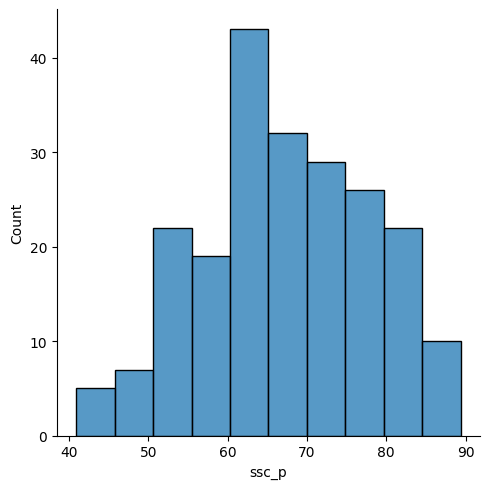

In [30]:
import seaborn as sns

sns.displot(dataset['ssc_p'])

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

Mean: 67.30339534883721, Standard: 10.827205398231452
Prob:  [np.float64(0.010275148846718499), np.float64(0.011858764583155554), np.float64(0.013570194930153937), np.float64(0.015396713811418094), np.float64(0.01732069447798158), np.float64(0.019319588759641553), np.float64(0.021366125100358083), np.float64(0.023428741938312646), np.float64(0.025472260251149254), np.float64(0.027458784613159832), np.float64(0.029348806868826963), np.float64(0.031102471650606527), np.float64(0.03268094966902733), np.float64(0.034047854157679046), np.float64(0.03517062909285573), np.float64(0.036021835597530534), np.float64(0.03658026570377481), np.float64(0.03683182040123766), np.float64(0.03677010122906173), np.float64(0.03639668075742896)]
Sum of probabilities:  0.5304184324400784
Area in range of 50 & 70 is 0.5304184324400784


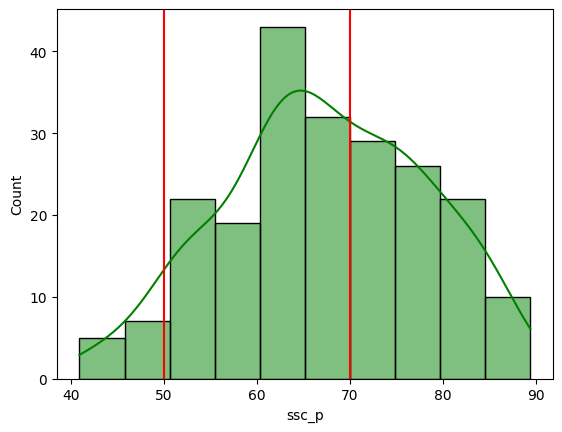

In [ ]:
def pdf(dataset, start, end):

    # Plot histogram with KDE curve
    # Histogram shows frequency distribution
    # KDE shows smooth probability density curve
    sns.histplot(dataset, kde=True, color="Green")

    # Draw vertical boundary lines for the given range
    plt.axvline(start, color="Red")  # Left boundary
    plt.axvline(end, color="Red")  # Right boundary

    sample = dataset
    mean = sample.mean()
    sd = sample.std()

    print(f"Mean: {mean}, Standard Deviation: {sd}")

    # Create a normal distribution object
    # This assumes the dataset follows a normal distribution
    distribution = norm(mean, sd)

    #  Generate values within the specified range
    values = [value for value in range(start, end)]

    #  Calculate PDF (probability density) for each value
    # PDF gives height of the curve at each point
    prob = [distribution.pdf(value) for value in values]
    print("PDF values: ", prob)

    # Approximate total probability in the given range
    probabilities = sum(prob)

    print("Sum of PDF values (approx area): ", probabilities)
    print(f"Area in range of {start} & {end} is {probabilities}")


pdf(new_dataset["ssc_p"], 50, 70)

In [ ]:
from statsmodels.distributions.empirical_distribution import ECDF

ecfd = ECDF(new_dataset['ssc_p'])
ecfd(80)

np.float64(0.8651162790697674)

<Axes: ylabel='Count'>

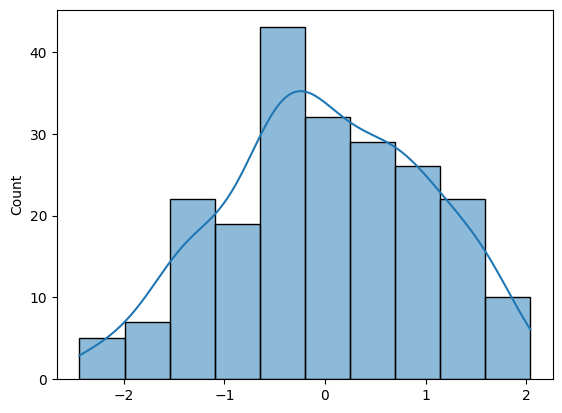

In [ ]:
# Converting 'ssc_p' column to Standard Normal Distribution (Z-score)

# Step 1: Calculate the mean (average) of the column
mean = new_dataset["ssc_p"].mean()

# Step 2: Calculate the standard deviation (measure of spread)
std = new_dataset["ssc_p"].std()

# Step 3: Extract all values from the column into a list
# (Each value represents one observation in the dataset)
values = [i for i in new_dataset["ssc_p"]]

# Step 4: Apply Z-score formula to standardize each value
# Z = (X - mean) / standard_deviation
# This transforms the data so that:
# - Mean becomes approximately 0
# - Standard deviation becomes approximately 1
z_score = [((j - mean) / std) for j in values]

# Step 5: Plot the standardized values
sns.histplot(z_score, kde=True)